In [1]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
%pip install mysql-connector-python pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


Connect Python with MySQL

In [3]:
import mysql.connector

# Connect only to MySQL server
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="admin"
)

cursor = conn.cursor()

print("Connected Successfully")

Connected Successfully


Create Database

In [4]:
cursor.execute("CREATE DATABASE IF NOT EXISTS expense_tracker")

print("Database Created Successfully")

Database Created Successfully


In [5]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="admin",
    database="expense_tracker"
)

cursor = conn.cursor()

print("Connected to expense_tracker")

Connected to expense_tracker


In [6]:
database="expense_tracker"

Create Transactions Table

In [7]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS transactions (
    id INT AUTO_INCREMENT PRIMARY KEY,
    amount FLOAT,
    category VARCHAR(100),
    type VARCHAR(50),
    date DATE,
    note VARCHAR(255)
)
""")

conn.commit()

Add Income/Expense Data

In [8]:
sql = """
INSERT INTO transactions
(amount, category, type, date, note)
VALUES (%s, %s, %s, %s, %s)
"""

values = (5000, "Salary", "Income", "2026-05-01", "Monthly Salary")

cursor.execute(sql, values)

conn.commit()

print("Data Inserted")

Data Inserted


View All Transactions

In [9]:
query = "SELECT * FROM transactions"

df = pd.read_sql(query, conn)

df

C:\Users\user\AppData\Local\Temp\ipykernel_3204\1460850159.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,amount,category,type,date,note
0,1,5000.0,Salary,Income,2026-05-01,Monthly Salary
1,2,1500.0,food,Expense,2026-05-15,Dinner
2,3,800.0,Travel,Expense,2026-05-02,Bus
3,4,1200.0,Shopping,Expense,2026-05-03,Clothes
4,5,1500.0,food,expense,2026-05-25,dinner
5,6,5000.0,salary,Income,2026-05-01,Salary
6,7,5000.0,Salary,Income,2026-05-01,Monthly Salary
7,8,1000.0,Food,Expense,2026-05-01,Lunch
8,9,800.0,Travel,Expense,2026-05-02,Bus
9,10,1200.0,Shopping,Expense,2026-05-03,Clothes


Calculate Total Income

In [10]:
query = """
SELECT SUM(amount) AS Total_Income
FROM transactions
WHERE type='Income'
"""

income = pd.read_sql(query, conn)

income

C:\Users\user\AppData\Local\Temp\ipykernel_3204\2997423892.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  income = pd.read_sql(query, conn)


,Total_Income
0,20000.0


Calculate Total Expenses

In [11]:
query = """
SELECT SUM(amount) AS Total_Expense
FROM transactions
WHERE type='Expense'
"""

expense = pd.read_sql(query, conn)

expense

C:\Users\user\AppData\Local\Temp\ipykernel_3204\2880217220.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  expense = pd.read_sql(query, conn)


,Total_Expense
0,31000.2


Savings Formula

In [12]:
total_income = income.iloc[0,0]
total_expense = expense.iloc[0,0]

# Handle NULL values
if total_income is None:
    total_income = 0

if total_expense is None:
    total_expense = 0

savings = total_income - total_expense

print("Savings =", savings)

Savings = -11000.20000000298


Monthly Summary

In [13]:
query = """
SELECT 
    MONTH(date) AS Month,
    SUM(amount) AS Total
FROM transactions
GROUP BY MONTH(date)
"""

monthly = pd.read_sql(query, conn)

monthly

C:\Users\user\AppData\Local\Temp\ipykernel_3204\1800258277.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthly = pd.read_sql(query, conn)


,Month,Total
0,5,51000.2


Budget Tracking

In [14]:
budget = 10000

In [15]:
remaining = budget - total_expense

print("Remaining Budget =", remaining)

if total_expense > budget:
    print("Budget Exceeded!")
else:
    print("Budget Under Control")

Remaining Budget = -21000.20000000298
Budget Exceeded!


In [16]:
sql = """
INSERT INTO transactions
(amount, category, type, date, note)
VALUES (%s, %s, %s, %s, %s)
"""

data = [
    (1000, "Food", "Expense", "2026-05-01", "Lunch"),
    (800, "Travel", "Expense", "2026-05-02", "Bus"),
    (1200, "Shopping", "Expense", "2026-05-03", "Clothes")
]

cursor.executemany(sql, data)

conn.commit()

print("Expense Data Inserted")

Expense Data Inserted


Automatically data store

In [17]:
def update_transaction():

    transaction_id = int(input("Enter Transaction ID to Update: "))

    new_amount = float(input("Enter New Amount: "))
    new_category = input("Enter New Category: ")
    new_type = input("Enter New Type (Income/Expense): ").capitalize()
    new_date = input("Enter New Date (YYYY-MM-DD): ")
    new_note = input("Enter New Note: ")

    sql = """
    UPDATE transactions
    SET amount=%s,
        category=%s,
        type=%s,
        date=%s,
        note=%s
    WHERE id=%s
    """

    values = (
        new_amount,
        new_category,
        new_type,
        new_date,
        new_note,
        transaction_id
    )

    cursor.execute(sql, values)

    conn.commit()

    print("Transaction Updated Successfully")

Delete Transaction Code

In [18]:
def delete_transaction():

    transaction_id = int(input("Enter Transaction ID to Delete: "))

    sql = "DELETE FROM transactions WHERE id=%s"

    values = (transaction_id,)

    cursor.execute(sql, values)

    conn.commit()

    print("Transaction Deleted Successfully")

Updated Menu System

In [19]:
while True:

    print("\n===== EXPENSE TRACKER =====")
    print("1. Add Transaction")
    print("2. View Transactions")
    print("3. Update Transaction")
    print("4. Delete Transaction")
    print("5. Exit")

    choice = input("Enter Choice: ")

    if choice == '1':

        add_transaction()

    elif choice == '2':

        query = "SELECT * FROM transactions"

        df = pd.read_sql(query, conn)

        print(df)

    elif choice == '3':

        update_transaction()

    elif choice == '4':

        delete_transaction()

    elif choice == '5':

        print("Program Closed")

        break

    else:

        print("Invalid Choice")


===== EXPENSE TRACKER =====
1. Add Transaction
2. View Transactions
3. Update Transaction
4. Delete Transaction
5. Exit
Program Closed


Pie Chart

C:\Users\user\AppData\Local\Temp\ipykernel_3204\491633519.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  chart_data = pd.read_sql(query, conn)


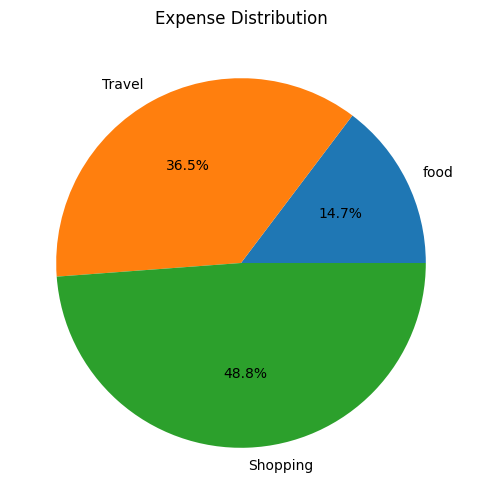

In [20]:
query = """
SELECT category, SUM(amount) as total
FROM transactions
WHERE type='Expense'
GROUP BY category
"""

chart_data = pd.read_sql(query, conn)

plt.figure(figsize=(6,6))

plt.pie(
    chart_data['total'],
    labels=chart_data['category'],
    autopct='%1.1f%%'
)

plt.title("Expense Distribution")

plt.show()

Bar Chart (Income vs Expense)

C:\Users\user\AppData\Local\Temp\ipykernel_3204\507501897.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  bar_data = pd.read_sql(query, conn)


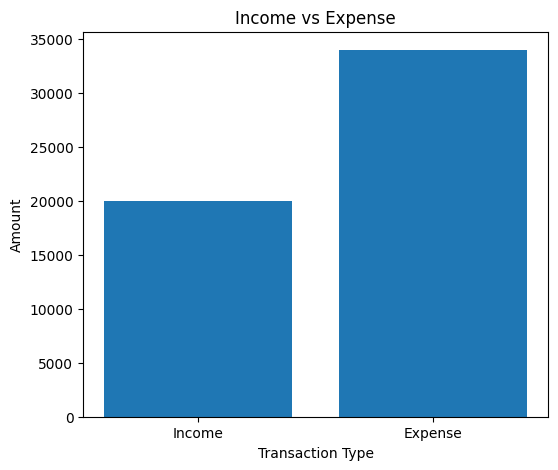

In [21]:
query = """
SELECT type, SUM(amount) as total
FROM transactions
GROUP BY type
"""

bar_data = pd.read_sql(query, conn)

plt.figure(figsize=(6,5))

plt.bar(
    bar_data['type'],
    bar_data['total']
)

plt.xlabel("Transaction Type")
plt.ylabel("Amount")
plt.title("Income vs Expense")

plt.show()

Line Chart (Monthly Expense Trend)

C:\Users\user\AppData\Local\Temp\ipykernel_3204\2663249197.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  line_data = pd.read_sql(query, conn)


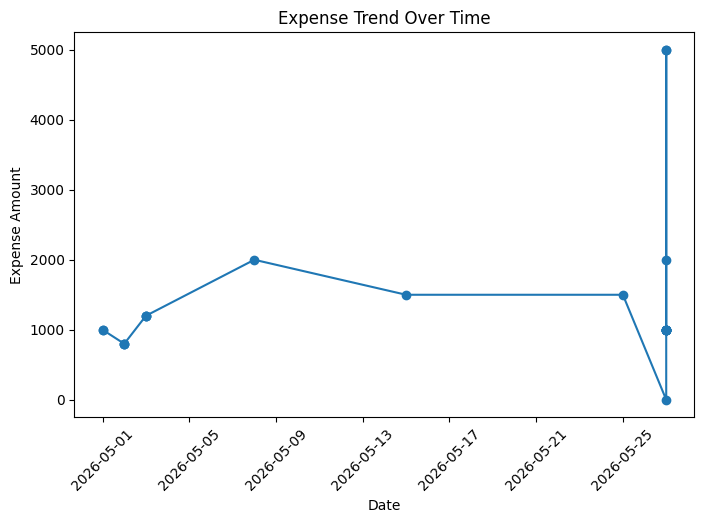

In [22]:
query = """
SELECT date, amount
FROM transactions
WHERE type='Expense'
ORDER BY date
"""

line_data = pd.read_sql(query, conn)

plt.figure(figsize=(8,5))

plt.plot(
    line_data['date'],
    line_data['amount'],
    marker='o'
)

plt.xlabel("Date")
plt.ylabel("Expense Amount")
plt.title("Expense Trend Over Time")

plt.xticks(rotation=45)

plt.show()

Category-wise Expense Bar Chart

C:\Users\user\AppData\Local\Temp\ipykernel_3204\2544670997.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  cat_data = pd.read_sql(query, conn)


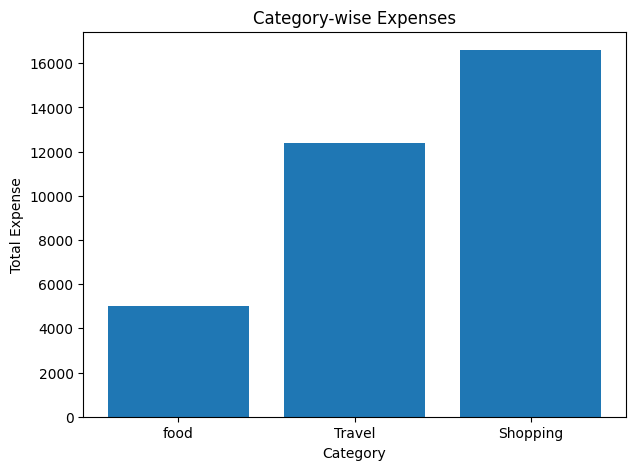

In [23]:
query = """
SELECT category, SUM(amount) as total
FROM transactions
WHERE type='Expense'
GROUP BY category
"""

cat_data = pd.read_sql(query, conn)

plt.figure(figsize=(7,5))

plt.bar(
    cat_data['category'],
    cat_data['total']
)

plt.xlabel("Category")
plt.ylabel("Total Expense")
plt.title("Category-wise Expenses")

plt.show()

Budget Tracking Graph

C:\Users\user\AppData\Local\Temp\ipykernel_3204\3038886385.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  expense = pd.read_sql(expense_query, conn)


ValueError: Wedge sizes 'x' must be non negative values

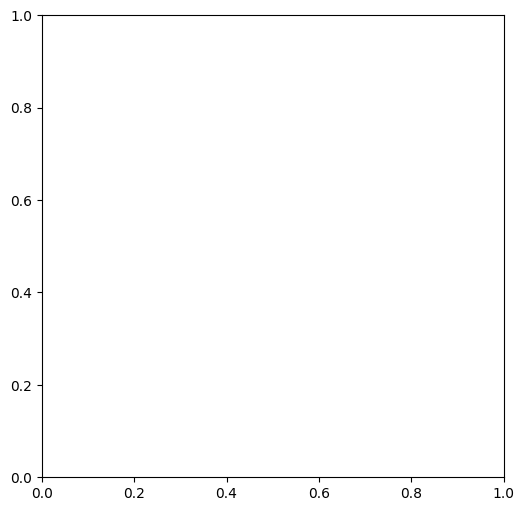

In [ ]:
budget = 10000

expense_query = """
SELECT COALESCE(SUM(amount),0) AS total_expense
FROM transactions
WHERE LOWER(type)='expense'
"""

expense = pd.read_sql(expense_query, conn)
total_expense = expense.iloc[0,0]

# 🔥 SAFE CALCULATION
remaining = max(0, budget - total_expense)

# optional: show warning
if total_expense > budget:
    print("⚠ Budget Exceeded!")

labels = ['Spent', 'Remaining']
values = [total_expense, remaining]

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title("Budget Tracking")
plt.show()